In [1]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from collections import Counter
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import pandas as pd
import numpy as np
import h5py
from tqdm import tqdm
import os

root = "."

In [2]:
# Load smiles
data = pd.read_csv(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
data['index'] = data.index
ind_to_id = {i: j for i,j in data[['index', 'id']].values}
id_to_ind = {i: j for i,j in data[['id', 'index']].values}

# Define some paths
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')
PATH_TO_INPUT_LIGANDS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'input_ligands')
PATH_TO_INFERENCES = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'inference_10M')
PATH_TO_RESULTS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'training_results')
os.makedirs(PATH_TO_INFERENCES, exist_ok=True)
os.makedirs(PATH_TO_RESULTS, exist_ok=True)

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [ ]:
# Load ECFPs
with h5py.File(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL_ECFP6.h5")) as h5:
    ids_ind = h5['ids'][:]
    fps = h5['fps'][:]
    # popc = h5['popc'][:10]
id_to_fp = {ind_to_id[i]:j for i,j in zip(ids_ind, fps)}
# del ids_ind, fps

In [ ]:
def predict_proba_batched(clf, X, batch_size=100_000):
    """
    Predict class-1 probabilities in batches to avoid OOM errors
    when X is very large. Results are identical to predict_proba.
    """
    probs = np.empty(X.shape[0], dtype=np.float32)

    for i in range(0, X.shape[0], batch_size):
        X_batch = X[i:i + batch_size]
        probs[i:i + batch_size] = clf.predict_proba(X_batch)[:, 1]

    return probs

In [ ]:
# # Get compounds in the train set
# COMPOUNDS_IN_TRAIN = []
# for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))):
#     lines = open(os.path.join(PATH_TO_INPUT_LIGANDS, f"input_ligands_{pocket}.txt"), "r").readlines()
#     lines = [i.strip().replace(".sdf", "").split("/")[-1] for i in lines]
#     COMPOUNDS_IN_TRAIN.extend(lines)
# COMPOUNDS_IN_TRAIN = set(COMPOUNDS_IN_TRAIN)

# # Get indices not in train
# IND_NOT_IN_TRAIN = set([i for i in ind_to_id if ind_to_id[i] not in COMPOUNDS_IN_TRAIN])

# # IDs not in train
# ids_not_in_train = sorted([ind_to_id[i] for i in IND_NOT_IN_TRAIN])
# del IND_NOT_IN_TRAIN

# # Saving IDs
# ids_not_in_train = pd.DataFrame(ids_not_in_train, columns = ['ids'])
# ids_not_in_train.to_csv(os.path.join(PATH_TO_INFERENCES, 'ids.csv.gz'), index=False)

# # Map sorted ids not in train back to ind
# IND_NOT_IN_TRAIN = np.array([id_to_ind[i] for i in ids_not_in_train['ids']])

# # Get indices to test fps
# s = set(IND_NOT_IN_TRAIN)
# IND_TEST =  np.array([c for c, id_ in enumerate(ids_ind) if id_ in s])

In [ ]:
IDS = pd.DataFrame([ind_to_id[i] for i in ids_ind], columns = ['ids'])
IDS.to_csv(os.path.join(PATH_TO_INFERENCES, 'ids.csv.gz'), index=False)
del IDS
IDS = np.array([ind_to_id[i] for i in ids_ind])

In [ ]:
# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))):

    # Load results
    lines = open(os.path.join(PATH_TO_INPUT_LIGANDS, f"input_ligands_{pocket}.txt"), "r").readlines()
    lines = [i.strip().replace(".sdf", "").split("/")[-1] for i in lines]
    actives = set(lines[:100000])
    inactives = set(lines[100000:])
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
    scores['set'] = ["inactive" if i in inactives else "active" for i in scores['compound']]
    scores_actives = scores[scores['set'] == 'active'].reset_index(drop=True)
    scores_inactives = scores[scores['set'] == 'inactive'].reset_index(drop=True)
    DOCKING_RESULTS_REAL = {i: j for i, j in zip(scores_actives['compound'], scores_actives['score'])}
    DOCKING_RESULTS_REAL_BACKGROUND = {i: j for i, j in zip(scores_inactives['compound'], scores_inactives['score'])}
    del lines, actives, inactives, scores, scores_actives, scores_inactives

    # Create matrix
    docking_results = []
    for act in sorted(DOCKING_RESULTS_REAL):
        docking_results.append([act, DOCKING_RESULTS_REAL[act]])
    for back in sorted(DOCKING_RESULTS_REAL_BACKGROUND):
        docking_results.append([back, DOCKING_RESULTS_REAL_BACKGROUND[back]])
    docking_results = pd.DataFrame(docking_results, columns=['id', 'score']).sort_values('score').reset_index(drop=True)
    number_actives = 1130
    docking_results['Y'] = [1] * number_actives + [0] * (len(docking_results) - number_actives)
    compounds = np.array(docking_results['id'].tolist())
    Y = np.array(docking_results['Y'].tolist())
    X = np.array([id_to_fp[i] for i in compounds])
    perm = np.random.permutation(len(X))
    X, Y, compounds = X[perm], Y[perm], compounds[perm]

    # Train NB model
    clf = ComplementNB(alpha=1.0, norm=True)
    clf.fit(X, Y)
    y_score = clf.predict_proba(X)[:, 1]
    auc = round(roc_auc_score(Y, y_score), 5)
    del X, Y

    # Save results
    with open(os.path.join(PATH_TO_RESULTS, f"{pocket}_auroc.csv"), "w") as outfile:
        outfile.write("auroc\n")
        outfile.write(f"{auc}\n")

    # Run predict_proba on batches
    PROBS = predict_proba_batched(clf, fps)

    # Account for presence/absence of compound in the train set
    compounds = set(compounds)
    presence = np.array([True if cpd in compounds else False for cpd in IDS])

    # Save results
    np.savez_compressed(
    os.path.join(PATH_TO_INFERENCES, f"{pocket}_probs_presence.npz"),
    PROBS=PROBS.astype(np.float32),
    presence=presence.astype(np.bool_)
    )

In [3]:
AUROCS = []
for pocket in sorted(os.listdir(os.path.join(PATH_TO_RESULTS))):
    auroc = float(open(os.path.join(PATH_TO_RESULTS, pocket)).readlines()[1].strip())
    AUROCS.append(auroc)

AUROCS = np.array(AUROCS)[np.argsort(AUROCS)]

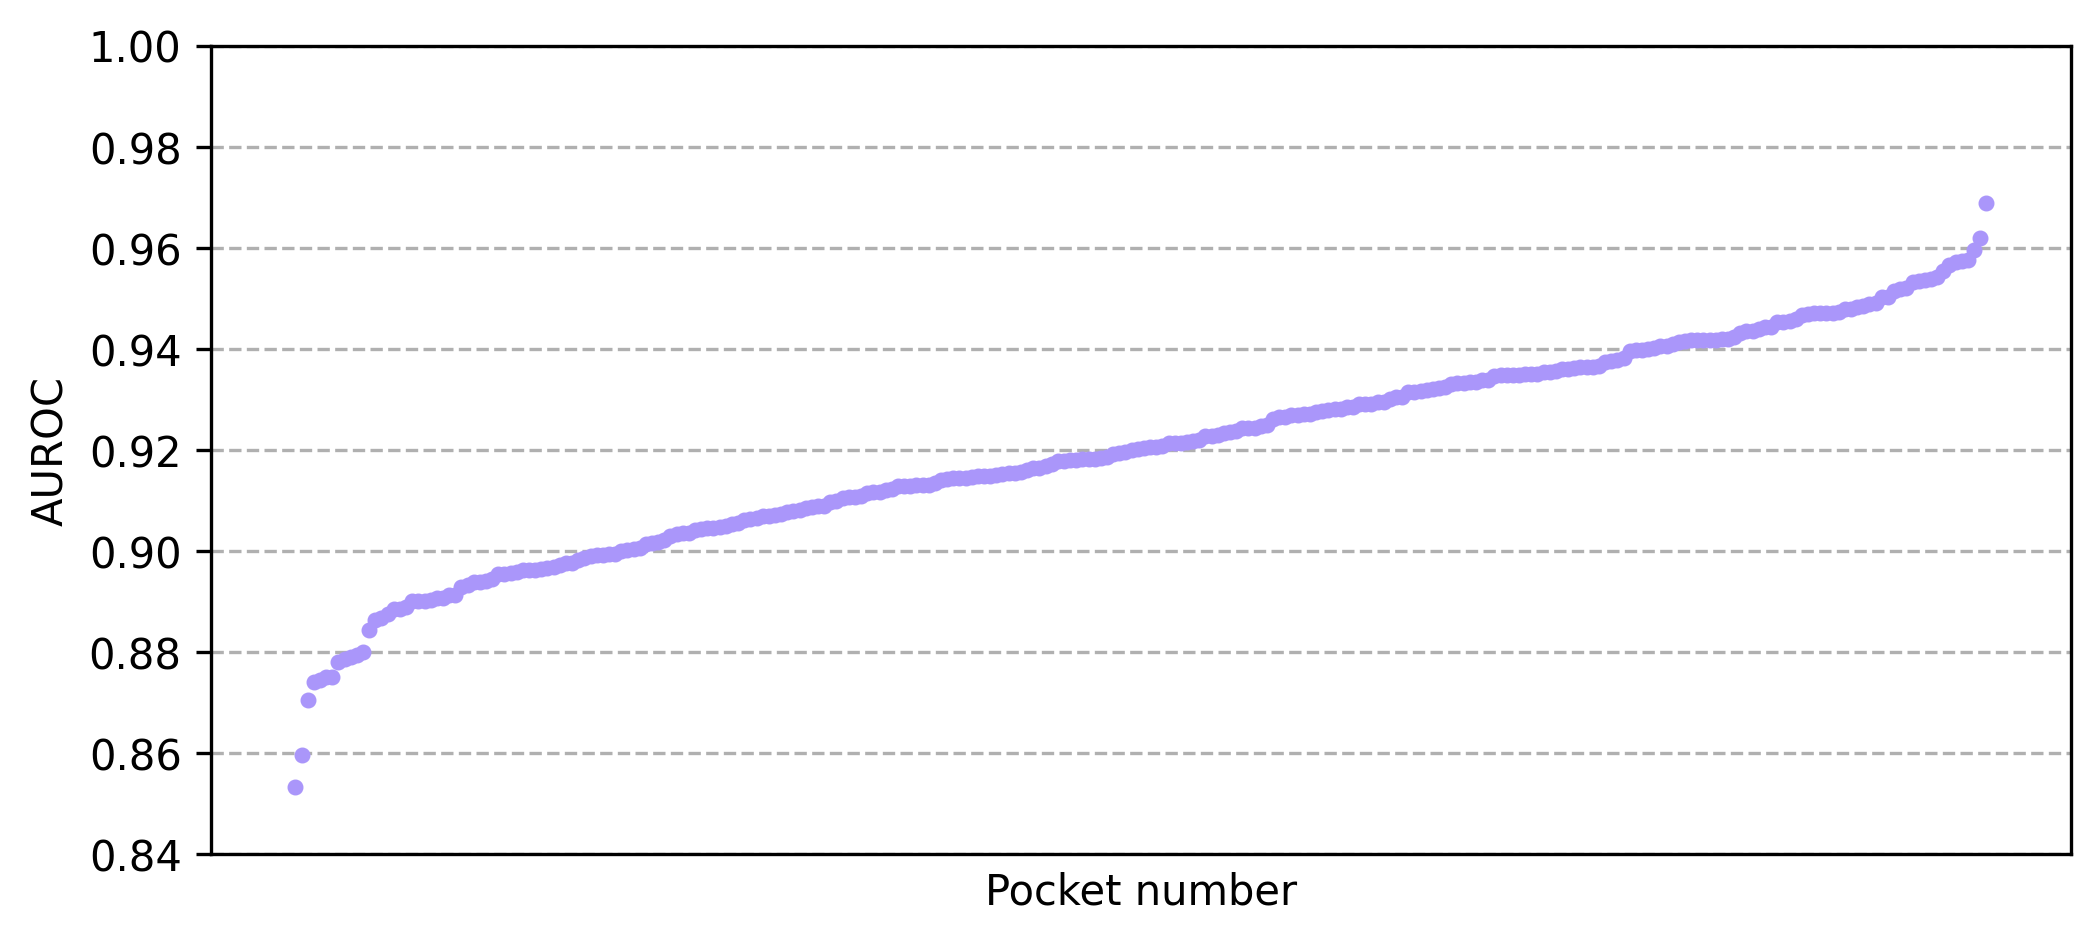

In [4]:
plt.figure(figsize=(8, 3.5))
plt.scatter([i for i in range(len(AUROCS))], AUROCS, s=8, zorder=2, c='#AA96FA')

plt.ylim([0.84, 1.00])
plt.ylabel("AUROC")
plt.xlabel("Pocket number")
plt.grid(linestyle='--')
plt.xticks([])
plt.show()

In [6]:
PATH_TO_DOCKING_RESULTS_REAL

'./../processed/unidock_REAL_docking/docking_results'

In [21]:
# Open H5 file
with h5py.File(os.path.join(root, "..", "processed", "unidock_REAL_docking", "probs_matrix.h5"), "w") as h5:

    # Create dataset
    N_pockets = 276
    N_compounds = 9_557_694
    dset = h5.create_dataset("probs", shape=(N_compounds, N_pockets), dtype=np.float32, 
                             chunks=(100_000, 1), compression="gzip", compression_opts=9)

    # For each pocket
    for col, pocket in tqdm(enumerate([i for i in sorted(os.listdir(os.path.join(PATH_TO_INFERENCES))) if 'probs' in i][:])):
        
        # Load probabilities
        data = np.load(os.path.join(PATH_TO_INFERENCES, pocket))
        probs = data["PROBS"]

        # Append probabilities to H5 file as a single column
        dset[:, col] = probs.astype(np.float32)

276it [22:28,  4.88s/it]
